# 100 meters world record

<img src="Images/100m.jpg" width="800"/>

[Men's 100 metres world record progression](https://en.wikipedia.org/wiki/Men's_100_metres_world_record_progression#Records_since_1977)
in wikipedia is written to file 'times_100m.dat'.

In [67]:
%cat 'times_100m.dat'

Time  | Wind | Auto  | Athlete        | Nationality   | Location of race      | Date
10.06 | 1.3  |       | Bob Hayes      | United States | Tokyo, Japan          | October 15, 1964
10.03 | 0.8  |       | Jim Hines      | United States | Sacramento, USA       | June 20, 1968
10.02 | 2.0  |       | Charles Greene | United States | Mexico City, Mexico   | October 13, 1968
 9.95 | 0.3  |       | Jim Hines      | United States | Mexico City, Mexico   | October 14, 1968
 9.93 | 1.4  |       | Calvin Smith   | United States | Colorado Springs, USA | July 3, 1983
 9.83 | 1.0  |       | Ben Johnson    | Canada        | Rome, Italy           | August 30, 1987
 9.93 | 1.1  |       | Carl Lewis     | United States | Rome, Italy           | August 30, 1987
 9.93 | 1.1  |       | Carl Lewis     | United States | Zürich, Switzerland   | August 17, 1988
 9.79 | 1.1  |       | Ben Johnson    | Canada        | Seoul, South Korea    | September 24, 1988
 9.92 | 1.1  |       | Carl Lewis     | United Sta

### Men's 100 meters world record example
1. **read** file data
1. store data in a data container  
   * store data as **list** (one element for line) of **lists** (one element for column, every line is stored as a list)
1. manage data to get **informations** about men's 100 meters world record

world record informations are loaded in data.

In [68]:
file_data = "times_100m.dat"        # file with data

with open(file_data, 'r') as f:     # open file in read mode
    keys = f.readline()             # read first line for keys
    data = []                       # empty list for data
    for line in f:                  # loop over file lines
        record = []                 # inialize one record with empty list
        for i in line.split("|"):   # loop over columns (split line with | separator)
            column = i.strip()      # strip column to remove blank space       
            record.append(column)   # append column to record list
        data.append(record)         # append record to data list

In [69]:
with open(file_data, 'r') as f:
    keys = f.readline()
    data = [ [ i.strip() for i in line.split("|") ] for line in f ]

dataset is a list

In [70]:
type(data)

list

every world record data is a list

In [71]:
type(data[0])

list

In [72]:
data[-1]

['9.58',
 '0.9',
 '9.572',
 'Usain Bolt',
 'Jamaica',
 'Berlin, Germany',
 'August 16, 2009']

In [73]:
for i in data: # loop over all world record
    print(i[0], " - ", i[3]) # print Time (1st column) and Athletes (4th column)

10.06  -  Bob Hayes
10.03  -  Jim Hines
10.02  -  Charles Greene
9.95  -  Jim Hines
9.93  -  Calvin Smith
9.83  -  Ben Johnson
9.93  -  Carl Lewis
9.93  -  Carl Lewis
9.79  -  Ben Johnson
9.92  -  Carl Lewis
9.90  -  Leroy Burrell
9.86  -  Carl Lewis
9.85  -  Leroy Burrell
9.84  -  Donovan Bailey
9.79  -  Maurice Greene
9.78  -  Tim Montgomery
9.77  -  Asafa Powell
9.77  -  Justin Gatlin
9.77  -  Asafa Powell
9.77  -  Asafa Powell
9.74  -  Asafa Powell
9.72  -  Usain Bolt
9.69  -  Usain Bolt
9.58  -  Usain Bolt


### How can we know column indices of the table?

The keys of the table are read by first line of file data

In [74]:
keys = [i.strip() for i in keys.split("|")]

keys

['Time', 'Wind', 'Auto', 'Athlete', 'Nationality', 'Location of race', 'Date']

We can get column index for a given key using `index` method of `list`

In [75]:
keys.index('Date')

6

Therefore we can access data also without explicit know column index

In [76]:
for i in data:
    print(i[keys.index('Time')], " - ", i[keys.index('Athlete')])

10.06  -  Bob Hayes
10.03  -  Jim Hines
10.02  -  Charles Greene
9.95  -  Jim Hines
9.93  -  Calvin Smith
9.83  -  Ben Johnson
9.93  -  Carl Lewis
9.93  -  Carl Lewis
9.79  -  Ben Johnson
9.92  -  Carl Lewis
9.90  -  Leroy Burrell
9.86  -  Carl Lewis
9.85  -  Leroy Burrell
9.84  -  Donovan Bailey
9.79  -  Maurice Greene
9.78  -  Tim Montgomery
9.77  -  Asafa Powell
9.77  -  Justin Gatlin
9.77  -  Asafa Powell
9.77  -  Asafa Powell
9.74  -  Asafa Powell
9.72  -  Usain Bolt
9.69  -  Usain Bolt
9.58  -  Usain Bolt


The solution of using a **list of lists** for storing data is **not optimal**
* column index should be known
* otherwise accessing data by key is not straightforward
* and not efficient (the `index` method is called every time)

# dictionary

<img src="Images/dict.png" width="700"/>

# dictionary

unordered set of key, value pairs with the requirement that the keys are unique.

* **unordered**: 
* **mutable**: key, value pair can be changed
* **indexed**: unlike sequences, dictionaries are indexed **by keys** (any immutable type)
    * **string** and **number** can always be keys
    * **tuple** can be keys only if contains immutable type (directly or indirectly)
* **dynamic**: key, value pairs can be added and removed


define an empty dictionary with curly braces `{}` or with built-in `dict` constructor

In [77]:
d = {}
d = dict()

create a dictionary by placing all pairs key/values, with the key separated from the values by a colon `:`, inside curly braces `{}` separated by comma

In [131]:
d = {'Athlete': 'Usain Bolt', 'Time': '9.58'}

In [135]:
d

{'Athlete': 'Usain Bolt', 'Time': '9.58'}

dictionary can be indexed by key listing the key inside squared bracket `[]`

In [136]:
print(d['Athlete'], " - ", d['Time'])

Usain Bolt  -  9.58


adding a pairs or changing its value is performed with item assignment

In [81]:
d['Nationality'] = 'Jamaica'
d

{'Athlete': 'Usain Bolt', 'Time': '9.58', 'Nationality': 'Jamaica'}

In [82]:
d.keys()

dict_keys(['Athlete', 'Time', 'Nationality'])

<div class="alert alert-info">

* `Dict.keys()` return a set-like object providing a view on Dict's keys

</div>

accessing a dictionary with a non existing key an exception of `KeyError` type is raised

In [137]:
d['Date']

KeyError: 'Date'

method `get` provide against raising exception for invalid keys

In [138]:
print(d.get('Date')) # return value of key if key is found otherwise return None value

None


In [139]:
print(d.get('Date', 'Unknown')) # if key is not found return 'Unknown'

Unknown


<div class="alert alert-info">

* `Dict.get(k[,d])` Dict[k] if k in Dict, else d.  d defaults to None.

</div>

## dictionary looping

looping through keys

In [140]:
for k in d.keys():
    print(k, "=", d[k])

Athlete = Usain Bolt
Time = 9.58


looping through values

In [87]:
d.values()

dict_values(['Usain Bolt', '9.58', 'Jamaica'])

<div class="alert alert-info">

* `Dict.values()` return an object providing a view on Dict's values

</div>

## dictionary looping

looping through items

In [141]:
for k, v in d.items():
    print(k, "=", v)

Athlete = Usain Bolt
Time = 9.58


<div class="alert alert-info">

* `Dict.items()` a set-like object providing a view on D's items

</div>

### Men's 100 meters world record example
1. **read** file data
1. store data in a data container
   * store data as **list** (one element for line) of **dictionaries** (one dictionary for world record)
   * dictionary keys taken from table keys and dictionary values from columns
1. manage data to get **informations** about men's 100 meters world record

In [142]:
with open(file_data, 'r') as f:
    
    # read keys from 1st line and store them in a list
    keys = [i.strip() for i in f.readline().split("|")] 
    
    data = []                            # empty list for data
    for line in f:                       # loop over file lines
        values = line.split("|")         # store column values in a list (split line)
        record = {}                      # inizialize one record with empty dictionary
        for k, v in zip(keys, values):   # loop over both keys and values
            record[k] = v.strip()        # add column value to record dictionary
        data.append(record)              # append record to data list

<div class="alert alert-info">

* `zip(iter1 [,iter2 [...]])` Return a zip object which returns a tuple where
  the i-th element comes from the i-th element of each iterable passed as argument.
  It continues until the shortest iterable is exhausted.
</div>

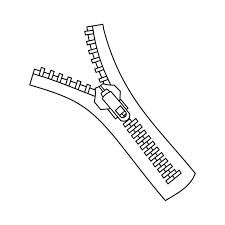

In [90]:
for (i, j, k) in zip(range(0, 3), range(1, 10), range(2, 20)):
    print(i, j, k)

0 1 2
1 2 3
2 3 4


In [91]:
with open(file_data, 'r') as f:  
    keys = [i.strip() for i in f.readline().split("|")]
    data = []
    for line in f:
        values = line.split("|")

        record = {k: v.strip() for k, v in zip(keys, values)}
        
        data.append(record)

dictionary comprehension is a concise way to create a dictionary

`{key: value for key, value in dictionary.items()}`

In [92]:
with open(file_data, 'r') as f:
    keys = [i.strip() for i in f.readline().split("|")]
    data = [ {k:v.strip() for k, v in zip(keys, line.split("|"))} for line in f]

In [93]:
for i in data:
    print(i['Time'], "-", i['Athlete'])

10.06 - Bob Hayes
10.03 - Jim Hines
10.02 - Charles Greene
9.95 - Jim Hines
9.93 - Calvin Smith
9.83 - Ben Johnson
9.93 - Carl Lewis
9.93 - Carl Lewis
9.79 - Ben Johnson
9.92 - Carl Lewis
9.90 - Leroy Burrell
9.86 - Carl Lewis
9.85 - Leroy Burrell
9.84 - Donovan Bailey
9.79 - Maurice Greene
9.78 - Tim Montgomery
9.77 - Asafa Powell
9.77 - Justin Gatlin
9.77 - Asafa Powell
9.77 - Asafa Powell
9.74 - Asafa Powell
9.72 - Usain Bolt
9.69 - Usain Bolt
9.58 - Usain Bolt


In [94]:
print('number of records =', len(data))

number of records = 24


data is stored in descending order, last is the fastest.
<br>
Better to store in ascending order (fastest as first)

In [95]:
data.reverse()

<div class="alert alert-info">

* `List.reverse()` reverse list order in place

</div>

In [96]:
for i in data:
    print(i['Time'], "-", i['Athlete'])

9.58 - Usain Bolt
9.69 - Usain Bolt
9.72 - Usain Bolt
9.74 - Asafa Powell
9.77 - Asafa Powell
9.77 - Asafa Powell
9.77 - Justin Gatlin
9.77 - Asafa Powell
9.78 - Tim Montgomery
9.79 - Maurice Greene
9.84 - Donovan Bailey
9.85 - Leroy Burrell
9.86 - Carl Lewis
9.90 - Leroy Burrell
9.92 - Carl Lewis
9.79 - Ben Johnson
9.93 - Carl Lewis
9.93 - Carl Lewis
9.83 - Ben Johnson
9.93 - Calvin Smith
9.95 - Jim Hines
10.02 - Charles Greene
10.03 - Jim Hines
10.06 - Bob Hayes


### plot date vs time

get all world record times in a list

In [97]:
time = [float(i['Time']) for i in data]

dates are in format "Month Day, Year"

In [98]:
data[0]['Date']

'August 16, 2009'

In [99]:
data[0]['Date'].split(',') # split date by comma

['August 16', ' 2009']

In [100]:
data[0]['Date'].split(',')[1] # get year

' 2009'

In [101]:
date = [ int(i['Date'].split(",")[1]) for i in data]

In [102]:
from datetime import datetime

#date = [datetime.strptime(i['Date'], '%B %d, %Y') for i in data]

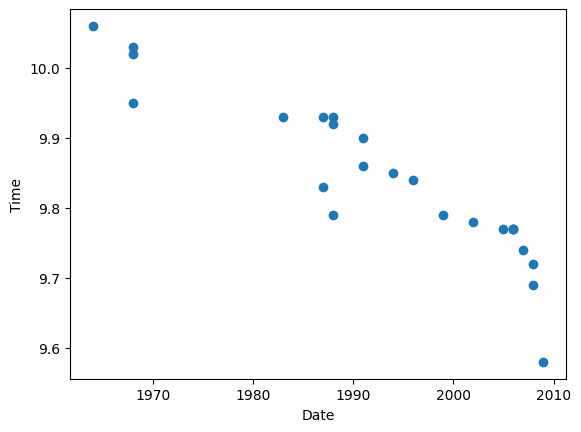

In [103]:
import matplotlib.pyplot as plt

plt.scatter(date, time)
plt.xlabel("Date")
plt.ylabel("Time")
plt.show()

In [104]:
doped_athletes = ["Tyson Gay", "Yohan Blake", "Tim Montgomery", "Ben Johnson"]

In [105]:
for i, item in enumerate(data):
    if item['Athlete'] in doped_athletes:
        data.remove(item)

In [106]:
for i, item in enumerate(data):
    if item['Athlete'] in doped_athletes:
        del data[i]

In [107]:
for d in data:
    print(d['Time'], d['Athlete'])
    
print("number of records =", len(data))

9.58 Usain Bolt
9.69 Usain Bolt
9.72 Usain Bolt
9.74 Asafa Powell
9.77 Asafa Powell
9.77 Asafa Powell
9.77 Justin Gatlin
9.77 Asafa Powell
9.79 Maurice Greene
9.84 Donovan Bailey
9.85 Leroy Burrell
9.86 Carl Lewis
9.90 Leroy Burrell
9.92 Carl Lewis
9.93 Carl Lewis
9.93 Carl Lewis
9.93 Calvin Smith
9.95 Jim Hines
10.02 Charles Greene
10.03 Jim Hines
10.06 Bob Hayes
number of records = 21


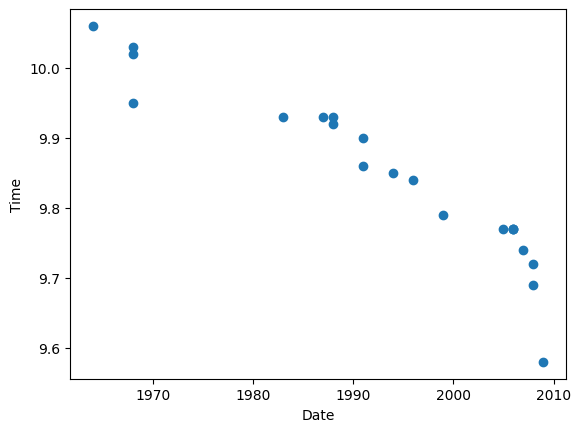

In [ ]:
time = [float(i['Time']) for i in data]
date = [ int(i['Date'].split(",")[1]) for i in data]

plt.scatter(date, time)
plt.xlabel("Date")
plt.ylabel("Time")
plt.show()

### A new 100 meters world record!!!

In [109]:
d = dict.fromkeys(keys)

d

{'Time': None,
 'Wind': None,
 'Auto': None,
 'Athlete': None,
 'Nationality': None,
 'Location of race': None,
 'Date': None}

<div class="alert alert-info">

* `Dict.fromkeys(iterable [, value])` Returns a new dict with keys from iterable and values equal to value.
   value is optional, If not provided default value is None.

</div>

In [110]:
# new world record

d['Athlete'] = 'Clark Kent'
d['Time'] = '9.42'
d['Nationality'] = 'Krypton'

d

{'Time': '9.42',
 'Wind': None,
 'Auto': None,
 'Athlete': 'Clark Kent',
 'Nationality': 'Krypton',
 'Location of race': None,
 'Date': None}

In [111]:
data.insert(0, d)

for d in data:
    print(d['Time'], "-", d['Athlete'])

9.42 - Clark Kent
9.58 - Usain Bolt
9.69 - Usain Bolt
9.72 - Usain Bolt
9.74 - Asafa Powell
9.77 - Asafa Powell
9.77 - Asafa Powell
9.77 - Justin Gatlin
9.77 - Asafa Powell
9.79 - Maurice Greene
9.84 - Donovan Bailey
9.85 - Leroy Burrell
9.86 - Carl Lewis
9.90 - Leroy Burrell
9.92 - Carl Lewis
9.93 - Carl Lewis
9.93 - Carl Lewis
9.93 - Calvin Smith
9.95 - Jim Hines
10.02 - Charles Greene
10.03 - Jim Hines
10.06 - Bob Hayes


# Function with arbitrary number of arguments

a **non-keyworded arbitrary number** of positional arguments can be passed to a function.
The positional arguments are placed in a **tuple**

In [112]:
def f(*args):
    """function with variable number of arguments"""
    print("args :", args)
    print("type :", type(args))

In [113]:
f('a', 'b', 'c')

args : ('a', 'b', 'c')
type : <class 'tuple'>


single-asterisk form `*` can be mixed with ordinary list of arguments of a function

In [114]:
def f(a, b, c, *args):
    """function with both fixed positional arguments and variable list of arguments"""
    print("formal :", a, b, c)
    print("args   :", args)

In [115]:
f('a', 'b', 'c')

formal : a b c
args   : ()


In [116]:
f('a', 'b', 'c', 'd', 'e')

formal : a b c
args   : ('d', 'e')


**unpacking** non-keyworded arguments from a tuple

In [117]:
t = ('a', 'b', 'c', 'd', 'e')

f(*t)

formal : a b c
args   : ('d', 'e')


a **keyworded arbitrary number** of arguments can be passed to a function.
<br>
When the arbitrary number of arguments are passed **by name** they are stored in a **dictionary**

In [118]:
def f(**kwargs):
    """function with variable number of arguments passed by name"""
    print("kwargs :", kwargs)
    print("type   :", type(kwargs))

In [119]:
f(a='a', b='b', c='c')

kwargs : {'a': 'a', 'b': 'b', 'c': 'c'}
type   : <class 'dict'>


double-asterisk form `**` can be mixed with ordinary list of arguments of a function

In [120]:
def f(a, b, c, **kwargs):
    """function with both fixed positional arguments
       and variable list of arguments passed by name"""
    print("formal :", a, b, c)
    print("kwargs :", kwargs)

In [121]:
f(a='a', b='b', c='c')

formal : a b c
kwargs : {}


In [122]:
f(a='a', b='b', c='c', d='d', e='e')

formal : a b c
kwargs : {'d': 'd', 'e': 'e'}


**unpacking** keyworded arguments from a dictionary

In [123]:
d = {'a': 'a', 'b': 'b', 'c': 'c', 'd': 'd', 'e': 'e'}

f(**d)

formal : a b c
kwargs : {'d': 'd', 'e': 'e'}


mixing all together: **ordinary** arguments, **non-keyworded** and **keyworded** variable length arguments list

In [124]:
def f(a, b, c, *args, **kwargs):
    """function with formal arguments and
       arbitrary number of list arguments positional and passed by name"""
    print("formal :", a, b, c)
    print("args   :", args)
    print("kwargs :", kwargs)

In [125]:
f('a', 'b', 'c', 'd', 'e')

formal : a b c
args   : ('d', 'e')
kwargs : {}


In [126]:
f(a='a', b='b', c='c', d='d', e='e')

formal : a b c
args   : ()
kwargs : {'d': 'd', 'e': 'e'}


In [127]:
f('a', 'b', 'c', 'd', e='e')

formal : a b c
args   : ('d',)
kwargs : {'e': 'e'}


**NB-1**: using name **\*args** and **\*\*kwargs** is just a convention.

**NB-2**: respect order (**formal, \*args, \*\*kwargs**)

In [ ]:
with open(file_data, 'r') as f:
    keys = [i.strip() for i in f.readline().split("|")]
    data = [ {k:v.strip() for k, v in zip(keys, line.split("|"))} for line in f]
    
print("\n", keys, "\n", data)

print(type(data))

for v in data:
    print("=", v)


 ['Time', 'Wind', 'Auto', 'Athlete', 'Nationality', 'Location of race', 'Date'] 
 [{'Time': '10.06', 'Wind': '1.3', 'Auto': '', 'Athlete': 'Bob Hayes', 'Nationality': 'United States', 'Location of race': 'Tokyo, Japan', 'Date': 'October 15, 1964'}, {'Time': '10.03', 'Wind': '0.8', 'Auto': '', 'Athlete': 'Jim Hines', 'Nationality': 'United States', 'Location of race': 'Sacramento, USA', 'Date': 'June 20, 1968'}, {'Time': '10.02', 'Wind': '2.0', 'Auto': '', 'Athlete': 'Charles Greene', 'Nationality': 'United States', 'Location of race': 'Mexico City, Mexico', 'Date': 'October 13, 1968'}, {'Time': '9.95', 'Wind': '0.3', 'Auto': '', 'Athlete': 'Jim Hines', 'Nationality': 'United States', 'Location of race': 'Mexico City, Mexico', 'Date': 'October 14, 1968'}, {'Time': '9.93', 'Wind': '1.4', 'Auto': '', 'Athlete': 'Calvin Smith', 'Nationality': 'United States', 'Location of race': 'Colorado Springs, USA', 'Date': 'July 3, 1983'}, {'Time': '9.83', 'Wind': '1.0', 'Auto': '', 'Athlete': 'Ben J

ValueError: too many values to unpack (expected 2)